# Algoritmo Genético del Asesor de Inversiones
**Fuente:** Benítez Iglésias, R. (2014). *Inteligencia artificial avanzada*. Editorial UOC.

El objetivo es encontrar qué cantidad de bonos debe comprar el cliente para **maximizar el rendimiento** sin exceder el capital disponible.

## Parte 1 — Implementación según la bibliografía

In [1]:
from random import random, randint, sample
from collections import namedtuple
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

In [2]:
# ── Funciones de evaluación ──────────────────────────────────────────────────

def capitalInvertido(individuo):
    """Calcula el capital invertido por un individuo."""
    return sum(map(lambda x, y: x * y.precio, individuo, inversiones))

def rendimiento(individuo):
    """Calcula el rendimiento obtenido por un individuo."""
    return sum(map(lambda x, y: x * y.precio * y.rendim,
                   individuo, inversiones))

# ── Operadores genéticos ─────────────────────────────────────────────────────

def ajustaCapital(individuo):
    """Si un individuo gasta más capital del disponible,
    elimina aleatoriamente inversiones hasta ajustarse."""
    ajustado = individuo[:]
    while capitalInvertido(ajustado) > capital:
        pos = randint(0, len(ajustado) - 1)
        if ajustado[pos] > 0:
            ajustado[pos] -= 1
    return ajustado

def creaIndividuo(inversiones, capital):
    """Crea un individuo al azar cuyas inversiones no excedan el capital."""
    individuo = [0] * len(inversiones)
    while capitalInvertido(individuo) < capital:
        eleccion = randint(0, len(inversiones) - 1)
        individuo[eleccion] += 1
    return ajustaCapital(individuo)

def cruza(poblacion, posiciones):
    """Crea un nuevo individuo cruzando dos progenitores."""
    L = len(poblacion[0])
    hijo    = poblacion[posiciones[0]][:]
    inicio  = randint(0, L - 1)
    fin     = randint(inicio + 1, L)
    hijo[inicio:fin] = poblacion[posiciones[1]][inicio:fin]
    return ajustaCapital(hijo)

def muta(individuo, tasaMutacion):
    """Aplica mutaciones con cierta probabilidad."""
    mutado = []
    for i in range(len(individuo)):
        if random() > tasaMutacion:
            mutado.append(individuo[i])
        else:
            mutado.append(randint(0, inversiones[i].cantidad))
    return ajustaCapital(mutado)

def evoluciona(poblacion, generaciones):
    """Hace evolucionar el sistema durante un número de generaciones."""
    poblacion.sort(key=lambda x: rendimiento(x))
    N            = len(poblacion)
    tasaMutacion = 0.01
    # Lista de probabilidades de reproducción
    reproduccion = [x for x in range(N) for y in range(x + 1)]
    historial    = [rendimiento(poblacion[-1])]

    for i in range(generaciones):
        padres = sample(reproduccion, 2)
        while padres[0] == padres[1]:
            padres = sample(reproduccion, 2)
        hijos = [cruza(poblacion, padres) for x in range(N - 1)]
        hijos = [muta(x, tasaMutacion) for x in hijos]
        hijos.append(poblacion[-1])     # elitismo
        poblacion = hijos
        poblacion.sort(key=lambda x: rendimiento(x))
        historial.append(rendimiento(poblacion[-1]))

    return poblacion[-1], historial

In [3]:
# ── Datos del problema ───────────────────────────────────────────────────────
Inversion  = namedtuple('Inversion', 'precio cantidad rendim')

numInver   = 100
maxPrecio  = 1000
maxCant    = 10
maxRend    = 0.2

inversiones = [
    Inversion(random() * maxPrecio, randint(1, maxCant), random() * maxRend)
    for i in range(numInver)
]

capital      = 50_000
individuos   = 20
generaciones = 1_000

poblacion = [creaIndividuo(inversiones, capital) for _ in range(individuos)]

# ── Ejecución ────────────────────────────────────────────────────────────────
mejor, historial = evoluciona(poblacion, generaciones)

print(f"Capital invertido : ${capitalInvertido(mejor):,.2f}")
print(f"Rendimiento máximo: ${rendimiento(mejor):,.2f}")

Capital invertido : $49,963.10
Rendimiento máximo: $7,901.58


### Visualización — Cantidad de bonos a comprar por inversión

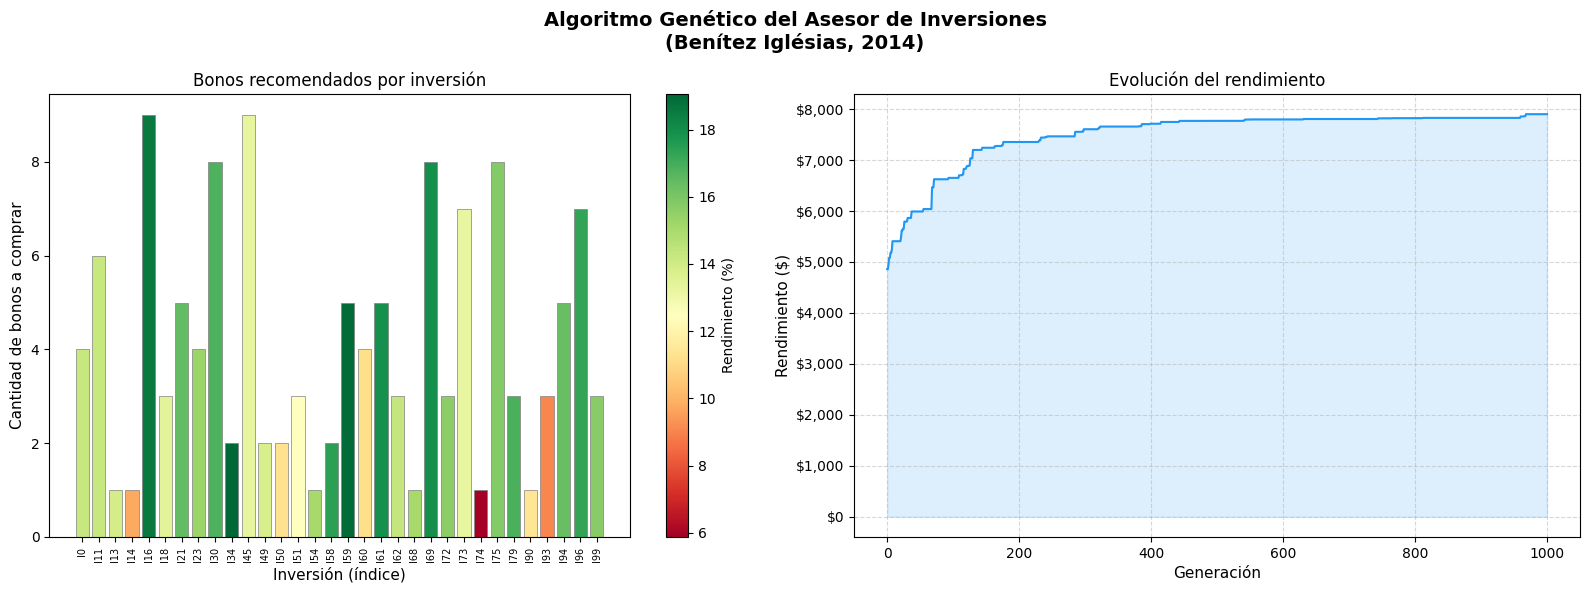


Inversiones seleccionadas: 32 de 100
Bonos totales a comprar  : 129


In [4]:
# ── Gráfica 1: Bonos a comprar por inversión (solo las no-cero) ─────────────
indices   = [i for i, v in enumerate(mejor) if v > 0]
cantidades = [mejor[i] for i in indices]
rendims   = [inversiones[i].rendim * 100 for i in indices]

colores = plt.cm.RdYlGn(
    [(r - min(rendims)) / (max(rendims) - min(rendims) + 1e-9) for r in rendims]
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Algoritmo Genético del Asesor de Inversiones\n'
             '(Benítez Iglésias, 2014)', fontsize=14, fontweight='bold')

# — Barras: cantidad de bonos por inversión —
bars = axes[0].bar(range(len(indices)), cantidades, color=colores, edgecolor='grey', linewidth=0.5)
axes[0].set_xlabel('Inversión (índice)', fontsize=11)
axes[0].set_ylabel('Cantidad de bonos a comprar', fontsize=11)
axes[0].set_title('Bonos recomendados por inversión', fontsize=12)
axes[0].set_xticks(range(len(indices)))
axes[0].set_xticklabels([f'I{i}' for i in indices], rotation=90, fontsize=7)
sm = plt.cm.ScalarMappable(cmap='RdYlGn',
     norm=plt.Normalize(vmin=min(rendims), vmax=max(rendims)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=axes[0])
cbar.set_label('Rendimiento (%)', fontsize=10)

# — Evolución del rendimiento por generación —
axes[1].plot(historial, color='#2196F3', linewidth=1.5)
axes[1].fill_between(range(len(historial)), historial, alpha=0.15, color='#2196F3')
axes[1].set_xlabel('Generación', fontsize=11)
axes[1].set_ylabel('Rendimiento ($)', fontsize=11)
axes[1].set_title('Evolución del rendimiento', fontsize=12)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('evolucion_ga_libro.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nInversiones seleccionadas: {len(indices)} de {numInver}")
print(f"Bonos totales a comprar  : {sum(cantidades)}")

---
## Parte 2 — Solución con la librería DEAP
**DEAP** (Distributed Evolutionary Algorithms in Python) es la librería estándar para algoritmos evolutivos en Python.

In [5]:
import array, random as rnd
from deap import base, creator, tools, algorithms

# ── Definir el problema (maximización) ──────────────────────────────────────
if 'FitnessMax' not in creator.__dict__:
    creator.create('FitnessMax', base.Fitness, weights=(1.0,))
if 'Individual' not in creator.__dict__:
    creator.create('Individual', list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

# Gen: cantidad de bonos entre 0 y maxCant para cada inversión
toolbox.register('gen_bono', rnd.randint, 0, maxCant)
toolbox.register('individual', tools.initRepeat,
                 creator.Individual, toolbox.gen_bono, n=numInver)
toolbox.register('population', tools.initRepeat, list, toolbox.individual)

# ── Función de aptitud ───────────────────────────────────────────────────────
def evaluar(individuo):
    """Devuelve el rendimiento; penaliza si se excede el capital."""
    cap = sum(x * inv.precio for x, inv in zip(individuo, inversiones))
    if cap > capital:
        return (-cap,)      # penalización fuerte
    rend = sum(x * inv.precio * inv.rendim for x, inv in zip(individuo, inversiones))
    return (rend,)

toolbox.register('evaluate', evaluar)
toolbox.register('mate',    tools.cxTwoPoint)
toolbox.register('mutate',  tools.mutUniformInt, low=0, up=maxCant, indpb=0.01)
toolbox.register('select',  tools.selTournament, tournsize=3)

print("DEAP configurado correctamente ✓")

DEAP configurado correctamente ✓


In [6]:
# ── Ejecutar el algoritmo evolutivo con DEAP ─────────────────────────────────
rnd.seed(42)
pop   = toolbox.population(n=individuos)
hof   = tools.HallOfFame(1)          # guarda el mejor individuo global
stats = tools.Statistics(lambda ind: ind.fitness.values[0])
stats.register('max',  np.max)
stats.register('mean', np.mean)

pop, log = algorithms.eaSimple(
    pop, toolbox,
    cxpb=0.7,      # probabilidad de cruce
    mutpb=0.01,    # probabilidad de mutación
    ngen=generaciones,
    stats=stats,
    halloffame=hof,
    verbose=False
)

mejor_deap = hof[0]
cap_deap   = sum(x * inv.precio for x, inv in zip(mejor_deap, inversiones))
rend_deap  = sum(x * inv.precio * inv.rendim for x, inv in zip(mejor_deap, inversiones))

print(f"Capital invertido : ${cap_deap:,.2f}")
print(f"Rendimiento máximo: ${rend_deap:,.2f}")

Capital invertido : $99,931.58
Rendimiento máximo: $8,563.45


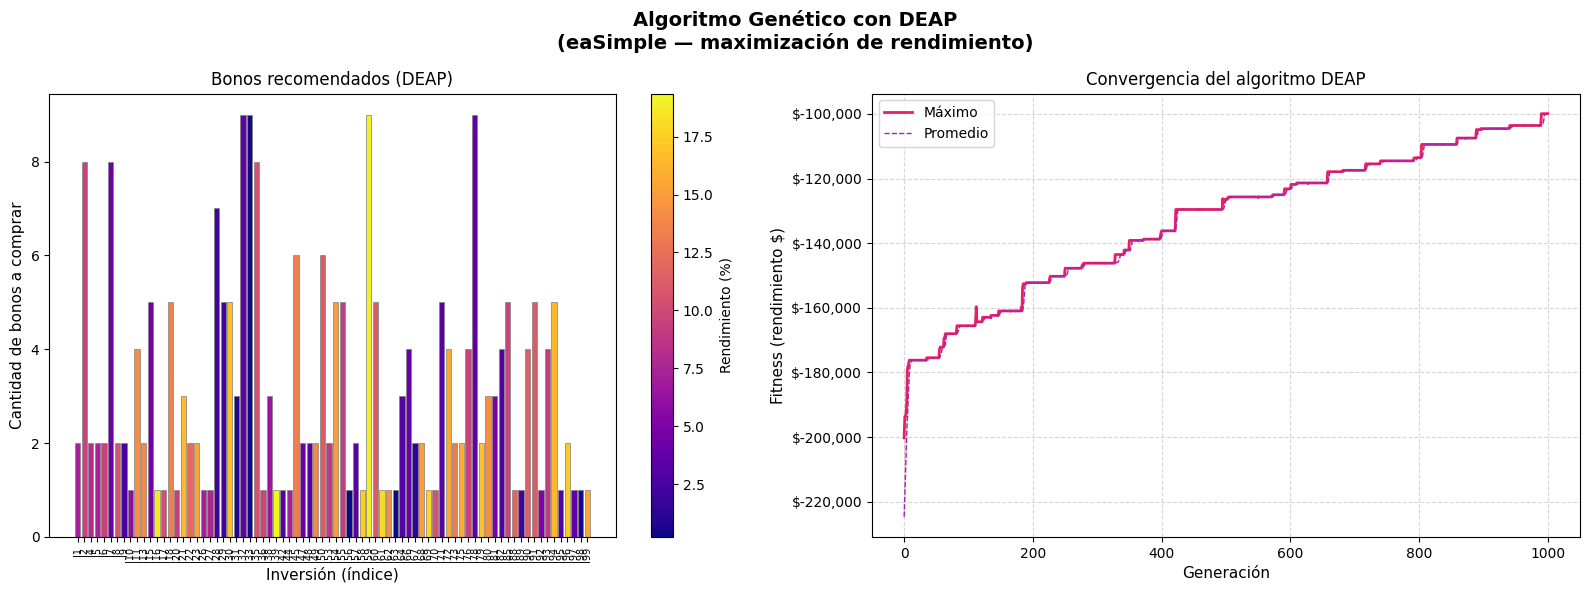


Inversiones seleccionadas: 78 de 100
Bonos totales a comprar  : 244


In [7]:
# ── Visualización DEAP ───────────────────────────────────────────────────────
gen_vals  = log.select('gen')
max_vals  = log.select('max')
mean_vals = log.select('mean')

idx_deap  = [i for i, v in enumerate(mejor_deap) if v > 0]
cant_deap = [mejor_deap[i] for i in idx_deap]
rend_deap_list = [inversiones[i].rendim * 100 for i in idx_deap]

col_deap = plt.cm.plasma(
    [(r - min(rend_deap_list)) / (max(rend_deap_list) - min(rend_deap_list) + 1e-9)
     for r in rend_deap_list]
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Algoritmo Genético con DEAP\n'
             '(eaSimple — maximización de rendimiento)', fontsize=14, fontweight='bold')

# — Bonos recomendados —
axes[0].bar(range(len(idx_deap)), cant_deap, color=col_deap, edgecolor='grey', linewidth=0.5)
axes[0].set_xlabel('Inversión (índice)', fontsize=11)
axes[0].set_ylabel('Cantidad de bonos a comprar', fontsize=11)
axes[0].set_title('Bonos recomendados (DEAP)', fontsize=12)
axes[0].set_xticks(range(len(idx_deap)))
axes[0].set_xticklabels([f'I{i}' for i in idx_deap], rotation=90, fontsize=7)
sm2 = plt.cm.ScalarMappable(cmap='plasma',
      norm=plt.Normalize(vmin=min(rend_deap_list), vmax=max(rend_deap_list)))
sm2.set_array([])
cbar2 = plt.colorbar(sm2, ax=axes[0])
cbar2.set_label('Rendimiento (%)', fontsize=10)

# — Evolución del fitness —
axes[1].plot(gen_vals, max_vals,  label='Máximo',  color='#E91E63', linewidth=2)
axes[1].plot(gen_vals, mean_vals, label='Promedio', color='#9C27B0', linewidth=1, linestyle='--')
axes[1].fill_between(gen_vals, mean_vals, max_vals, alpha=0.1, color='#E91E63')
axes[1].set_xlabel('Generación', fontsize=11)
axes[1].set_ylabel('Fitness (rendimiento $)', fontsize=11)
axes[1].set_title('Convergencia del algoritmo DEAP', fontsize=12)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].legend(fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('evolucion_ga_deap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nInversiones seleccionadas: {len(idx_deap)} de {numInver}")
print(f"Bonos totales a comprar  : {sum(cant_deap)}")

---
## Comparativa final

In [8]:
rend_libro = rendimiento(mejor)
cap_libro  = capitalInvertido(mejor)

print('=' * 50)
print(f"{'Método':<20} {'Capital':>13} {'Rendimiento':>13}")
print('-' * 50)
print(f"{'Bibliografía':<20} ${cap_libro:>12,.2f} ${rend_libro:>12,.2f}")
print(f"{'DEAP':<20} ${cap_deap:>12,.2f} ${rend_deap:>12,.2f}")
print('=' * 50)

Método                     Capital   Rendimiento
--------------------------------------------------
Bibliografía         $   49,963.10 $    7,901.58
DEAP                 $   99,931.58 $    8,563.45
